# 05. Advanced Modelling
## Objective

This notebook extends the baseline modelling analysis by evaluating an advanced nonlinear classifier on the Cleveland heart disease dataset.

The baseline experiments in 04_baseline_models.ipynb evaluated six classification algorithms using a common leakage-aware preprocessing pipeline and stratified five-fold cross-validation. Logistic Regression achieved the highest mean ROC-AUC of 0.9025 and was selected as the strongest baseline model.

The objective of this notebook is to determine whether an advanced nonlinear model can provide competitive or improved predictive performance while maintaining the same preprocessing and evaluation discipline.

A Gradient Boosting classifier is evaluated as the primary advanced model. Gradient Boosting is suitable for this task because it can model nonlinear relationships and interactions between predictors that may not be captured by a linear classifier.

The advanced model is evaluated using the same stratified five-fold cross-validation framework used for the baseline experiments. Preprocessing remains embedded within the modelling pipeline so that imputation, scaling, and categorical encoding are learned only from the training portion of each cross-validation fold.

The previously untouched test set remains reserved for final evaluation and is not used for model selection.

## 2. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the project root whether Jupyter was started from the repository root
# or from the notebooks/ directory.
PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src" / "preprocessing.py").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing src/preprocessing.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    load_data,
    prepare_features_target,
    create_model_pipeline,
    get_feature_groups,
    validate_columns,
)

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, auc,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42


## 3. Load Dataset

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "processed.cleveland.data"
df = load_data(DATA_PATH)
validate_columns(df)

print("Dataset path:", DATA_PATH.resolve())
print("Dataset shape:", df.shape)
display(df.head())


Dataset path: /mnt/data/refactor_validation/data/raw/processed.cleveland.data
Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 4. Prepare Predictors and Target

In [ ]:
X, y = prepare_features_target(df)
groups = get_feature_groups()
numerical_features = groups["numerical"]
categorical_features = groups["categorical"]

print("Predictor shape:", X.shape)
print("Target distribution:")
print(y.value_counts().sort_index())

assert X.shape[0] == 303
assert y.shape[0] == 303
assert set(y.unique()) == {0, 1}

Predictor shape: (303, 13)
Target distribution:
target
0    164
1    139
Name: count, dtype: int64


## 5. Stratified Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index().to_dict())

print("\nTest target distribution:")
print(y_test.value_counts())

Training shape: (242, 13)
Test shape: (61, 13)

Training target distribution:
{0: 131, 1: 111}

Test target distribution:
target
0    33
1    28
Name: count, dtype: int64


## 6. Advanced Model

XGBoost is used here as the project's advanced/ensemble model, consistent with the methodology documented in the literature-review workflow. The preprocessing is supplied by `src.preprocessing.create_model_pipeline()`.

### 6.1 Why Gradient Boosting?

Gradient Boosting was selected as the advanced model because it provides a nonlinear alternative to the Logistic Regression baseline.

Logistic Regression assumes that the relationship between the predictors and the log-odds of the target can be represented by a linear combination of the encoded predictors. Gradient Boosting instead constructs an ensemble of sequential decision trees, allowing the model to represent nonlinear relationships and interactions between predictors.

This provides a useful methodological contrast with the baseline models while remaining appropriate for the relatively small Cleveland dataset.

The default model configuration is used initially to avoid turning this notebook into a hyperparameter-optimization experiment. Any improvement over the baseline can therefore be interpreted as evidence associated with the modelling approach itself rather than extensive parameter tuning.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

advanced_pipeline = create_model_pipeline(
    xgb_model,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
)

print(advanced_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unk

## 7. Stratified Cross-Validation

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "specificity": make_scorer(recall_score, pos_label=0),
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_scores = cross_validate(
    advanced_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    error_score="raise",
    return_train_score=False,
)

advanced_cv = {
    metric: {
        "mean": cv_scores[f"test_{metric}"].mean(),
        "sd": cv_scores[f"test_{metric}"].std(ddof=0),
    }
    for metric in scoring
}

advanced_cv_df = pd.DataFrame(advanced_cv).T.rename(columns={"mean": "Mean", "sd": "SD"})
display(advanced_cv_df.round(4))


,Mean,SD
accuracy,0.7935,0.0289
precision,0.7763,0.0351
recall,0.7747,0.0576
specificity,0.8088,0.0432
f1,0.7740,0.0348
roc_auc,0.8614,0.0258


## 8. Fit Advanced Model and Evaluate on the Held-Out Test Set

In [7]:
advanced_pipeline.fit(X_train, y_train)
y_test_pred = advanced_pipeline.predict(X_test)
y_test_prob = advanced_pipeline.predict_proba(X_test)[:, 1]

advanced_test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "Specificity": recall_score(y_test, y_test_pred, pos_label=0),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob),
}

print("Advanced-model test metrics:")
for metric, value in advanced_test_metrics.items():
    print(f"{metric}: {value:.4f}")


Advanced-model test metrics:
Accuracy: 0.9016
Precision: 0.8438
Recall: 0.9643
Specificity: 0.8485
F1: 0.9000
ROC-AUC: 0.9567


## 9. Confusion Matrix and Classification Report

In [8]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_test_pred, digits=4))


Confusion matrix:
[[28  5]
 [ 1 27]]

Classification report:
              precision    recall  f1-score   support

           0     0.9655    0.8485    0.9032        33
           1     0.8438    0.9643    0.9000        28

    accuracy                         0.9016        61
   macro avg     0.9046    0.9064    0.9016        61
weighted avg     0.9096    0.9016    0.9017        61



## 10. ROC Curve

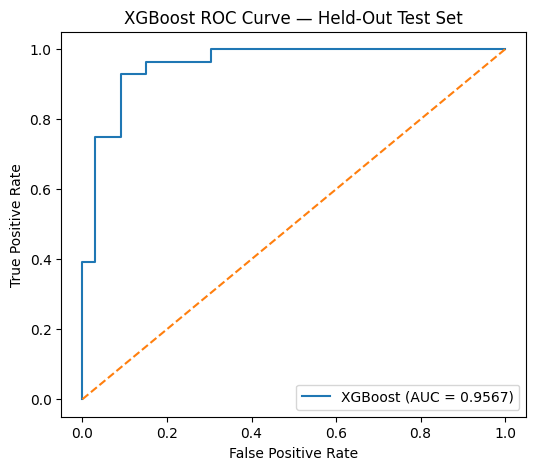

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve — Held-Out Test Set")
plt.legend()
plt.show()


## 11. Feature Importance

In [10]:
preprocessor = advanced_pipeline.named_steps["preprocessor"]
model = advanced_pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_,
}).sort_values("Importance", ascending=False)

display(importance_df.head(15).round(4))


,Feature,Importance
25,cat__thal_3.0,0.2594
10,cat__cp_4.0,0.0976
27,cat__thal_7.0,0.0765
21,cat__ca_0.0,0.0731
6,cat__sex_1.0,0.0439
7,cat__cp_1.0,0.0386
18,cat__slope_1.0,0.0385
19,cat__slope_2.0,0.0377
9,cat__cp_3.0,0.0375
5,cat__sex_0.0,0.0320


## 12. Interpretation and Scope

The reported values are results of this experiment only. The held-out test set contains 61 observations, so the test metrics should be interpreted with appropriate caution. Feature importance from XGBoost indicates model-usefulness within this fitted representation; it is not a causal or clinical importance measure. No claim of clinical deployment or universal superiority is made.

## 13. Reproducibility Checks

In [11]:
assert X.shape == (303, 13)
assert X_train.shape == (242, 13)
assert X_test.shape == (61, 13)
assert y_train.value_counts().sort_index().to_dict() == {0: 131, 1: 111}
assert y_test.value_counts().sort_index().to_dict() == {0: 33, 1: 28}
assert list(feature_names)

print("Reproducibility checks: PASSED")
print("Preprocessing source: src/preprocessing.py")
print("Advanced model: XGBoost")


Reproducibility checks: PASSED
Preprocessing source: src/preprocessing.py
Advanced model: XGBoost
